# DPAC Hyperparamter Tuning models on ALL Data

Logan Wong

law3082

Load the embeddings

DPAC did pretraining to learn features from images.
But I'm not using images, I'm using Tweets.
The Tweets were embedded into vectors using a pretrained LLM, all-mpnet-base-v2, which follows the SBERT architecture.

Do clustering using DPAC

Neither paper split their data into train/valid/test
So neither paper did hyperparameter tuning.

But, the DPAC paper had these hyperparameters:
Weight exponent, m: 1.03
Temperature, tau: 0.5
Adam Optimizer LR: 0.0001
1000 epochs for the pre-training step
200 epochs for the clustering step
Cluster number, K: predefined for the algorithms…

Incremental Clustering for Event Detection on Twitter paper had a dynamic incremental learning algo that did NOT need T, the # of clusters, predefined.

DPAC DID need K, the # of clusters, to be predefined.

In [1]:
import sys
import os

# Add the DPAC program folder to path
dpac_path = '/home/stu5/s5/law3082/Courses/MLDD/Deep-Probability-Aggregation-Clustering/PAC_DPAC_program/'
if dpac_path not in sys.path:
    sys.path.append(dpac_path)

In [2]:
import pandas as pd
import time

import argparse
import torch
import numpy as np
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import itertools

from models import Network 
from contrastive_loss import InfonceLoss
import torch.nn.functional as F

import matplotlib.pyplot as plt

# Evaluation metrics
# from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from sklearn.metrics.cluster import adjusted_mutual_info_score, adjusted_rand_score


In [3]:
os.environ["CUDA_VISIBLE_DEVICES"]="6"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
def convert(seconds):
    seconds = seconds % (24 * 3600)
    hour = seconds // 3600
    seconds %= 3600
    minutes = seconds // 60
    seconds %= 60

    return "%d:%02d:%02d" % (hour, minutes, seconds)

# Load Embeddings

In [5]:
embeddings_raw = np.load('data/event2012_embeddings.npy')
# Convert to a Float Tensor & move to GPU
embeddings = torch.from_numpy(embeddings_raw).float().to(device)

# Load the metadata to track tweet IDs
metadata = pd.read_csv('data/event2012_metadata.csv')

print(f"Loaded {embeddings.shape[0]} embeddings with dimension {embeddings.shape[1]}")

Loaded 68841 embeddings with dimension 768


In [6]:
# This class is based on ContrastiveLearningDataset, found in 
# /Courses/MLDD/Deep-Probability-Aggregation-Clustering/PAC_DPAC_program/data/
class TwitterVectorDataset(Dataset):
    def __init__(self, vecs):
        self.vecs = vecs
        
    def __len__(self):
        return len(self.vecs)

    def __getitem__(self, idx):
        x = self.vecs[idx]
        # DPAC expects (weak, strong, ori). 
        # "views" are simulated by adding 1% and 5% noise to the vectors.
        weak = x + torch.randn_like(x) * 0.01
        strong = x + torch.randn_like(x) * 0.05
        return (weak, strong, x), 0 # 0 is a placeholder label

In [7]:
# Initialize loader
dataset = TwitterVectorDataset(embeddings)
batch_size = 256
ins_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

# a mismatch between batch size and the number of tweets in the dataset
# total number of tweets isn't perfectly divisible by 256, the very last batch is smaller (a "partial batch")
# tell DataLoader to ignore the last tiny leftover piece of data
# DataLoader drops the "partial batch" 

In [8]:
# Define a Backbone for vectors
# original DPAC repo uses ResNet (which is for images)
# This is an MLP backbone to handle Twitter vectors
class TwitterBackbone(nn.Module):
    def __init__(self, input_dim=768, rep_dim=128):
        super().__init__()
        self.rep_dim = rep_dim # The Network class NEEDS this attribute
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, rep_dim)
        )
        
    def forward(self, x):
        return self.encoder(x)

In [9]:
# 768
input_dim = embeddings.shape[1]

# DPAC 'z' space dimension
feature_dim = 128    

# target number of clusters (events) aka class_num
num_events = 503

# Training

In [10]:
def train_model(model, ins_loader, optimizer, criterion, scaler, device, m):
    model.train()
    loss_epoch = {'loss1': 0, 'loss2': 0}
    
    for step, ((weak, strong, ori), _) in enumerate(ins_loader):
        # Move all versions of the tweet vector to the GPU
        weak = weak.to(device)
        strong = strong.to(device)
        ori = ori.to(device)
        
        # Concatenate weak and strong for contrastive learning
        img = torch.cat((weak, strong), dim=0)
        
        optimizer.zero_grad()
        
        with torch.amp.autocast('cuda'):
            # Forward pass
            z, p1, _ = model(img)
            
            # DPAC Clustering logic (Probability Aggregation)
            # Generate target distribution 'q'
            q, p = model.PAC_online(ori, m=m) 

            # model's last layer is a Linear layer, NOT softmax
            # THUS, convert raw logits (p1) into log-probabilities
            log_p1 = F.log_softmax(p1, dim=1)
            
            # Calculate Loss
            loss1 = criterion(z)         # Contrastive Loss (keeps tweets together)
            # loss2 = kldiv(q, p1)         # Clustering Loss (pushes tweets into events)
            loss2 = F.kl_div(log_p1, q, reduction='batchmean')
            
            loss = loss1 + loss2

        # Backprop
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        loss_epoch['loss1'] += loss1.item() / len(ins_loader)
        loss_epoch['loss2'] += loss2.item() / len(ins_loader)
        
    return loss_epoch

In [11]:
def plot_loss_curves(history, trial_idx, hps, ari, ami, save_path=None):
    """
    Plots the contrastive and clustering losses for a single tuning trial.
    Saves the plot if a save_path is provided.
    """
    plt.figure(figsize=(10, 5))
    plt.plot(history['contrastive'], label='Contrastive Loss', alpha=0.8)
    plt.plot(history['clustering'], label='Clustering Loss', alpha=0.8)
    
    # Dynamic title based on HPs and results
    title = (f"Trial {trial_idx+1}: m={hps['m']}, temp={hps['temp']}, lr={hps['lr']}\n"
             f"ARI: {ari:.4f}, AMI: {ami:.4f}")
    
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss Value')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to: {save_path}")
        
    plt.show()
    plt.close()

In [12]:
grid = {
    'm': [1.02, 1.03, 1.05, 1.07, 1.1],
    'temp': [0.3, 0.5, 0.7],
    'lr': [0.0001, 0.0003, 0.0005],
    'wd': [0.0001]
}

# grid = {
#     'm': [1.02,],
#     'temp': [0.3],
#     'lr': [0.0005],
#     'wd': [0.0001]
# }

# Create all combinations
keys, values = zip(*grid.items())
combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

In [13]:
combinations

[{'m': 1.02, 'temp': 0.3, 'lr': 0.0001, 'wd': 0.0001},
 {'m': 1.02, 'temp': 0.3, 'lr': 0.0003, 'wd': 0.0001},
 {'m': 1.02, 'temp': 0.3, 'lr': 0.0005, 'wd': 0.0001},
 {'m': 1.02, 'temp': 0.5, 'lr': 0.0001, 'wd': 0.0001},
 {'m': 1.02, 'temp': 0.5, 'lr': 0.0003, 'wd': 0.0001},
 {'m': 1.02, 'temp': 0.5, 'lr': 0.0005, 'wd': 0.0001},
 {'m': 1.02, 'temp': 0.7, 'lr': 0.0001, 'wd': 0.0001},
 {'m': 1.02, 'temp': 0.7, 'lr': 0.0003, 'wd': 0.0001},
 {'m': 1.02, 'temp': 0.7, 'lr': 0.0005, 'wd': 0.0001},
 {'m': 1.03, 'temp': 0.3, 'lr': 0.0001, 'wd': 0.0001},
 {'m': 1.03, 'temp': 0.3, 'lr': 0.0003, 'wd': 0.0001},
 {'m': 1.03, 'temp': 0.3, 'lr': 0.0005, 'wd': 0.0001},
 {'m': 1.03, 'temp': 0.5, 'lr': 0.0001, 'wd': 0.0001},
 {'m': 1.03, 'temp': 0.5, 'lr': 0.0003, 'wd': 0.0001},
 {'m': 1.03, 'temp': 0.5, 'lr': 0.0005, 'wd': 0.0001},
 {'m': 1.03, 'temp': 0.7, 'lr': 0.0001, 'wd': 0.0001},
 {'m': 1.03, 'temp': 0.7, 'lr': 0.0003, 'wd': 0.0001},
 {'m': 1.03, 'temp': 0.7, 'lr': 0.0005, 'wd': 0.0001},
 {'m': 1.0

# HP Tuning

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


HP Tuning started
COMBINATION 0: 
HYPERPARAMETERS: {'m': 1.02, 'temp': 0.3, 'lr': 0.0001, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:18<17:31, 10.52s/it]

Epoch [25/125] | Contrastive Loss: 3.2663 | Clustering Loss: 2.4475


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:34<12:48, 10.25s/it]

...

 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [17:08<04:15, 10.21s/it]

Epoch [100/125] | Contrastive Loss: 3.1762 | Clustering Loss: 2.5941


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [21:23<00:00, 10.27s/it]

Epoch [125/125] | Contrastive Loss: 3.1612 | Clustering Loss: 2.6703


NEW BEST ARI!!!
NEW BEST AMI!!!


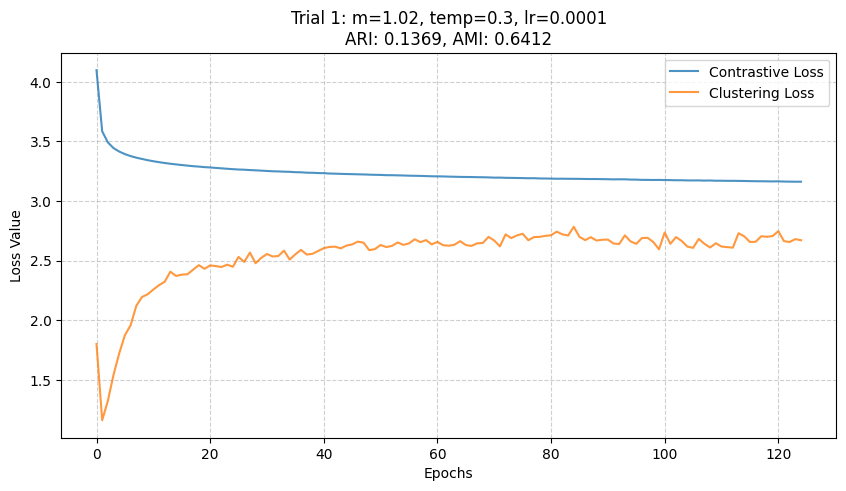

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.1369
AMI: 0.6412
COMBINATION 1: 
HYPERPARAMETERS: {'m': 1.02, 'temp': 0.3, 'lr': 0.0003, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:17<17:08, 10.28s/it]

Epoch [25/125] | Contrastive Loss: 3.1977 | Clustering Loss: 2.8805


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:34<12:39, 10.12s/it]

...

 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [17:04<04:20, 10.43s/it]

Epoch [100/125] | Contrastive Loss: 3.1263 | Clustering Loss: 2.9407


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [21:22<00:00, 10.26s/it]

Epoch [125/125] | Contrastive Loss: 3.1187 | Clustering Loss: 2.8278


NEW BEST ARI!!!
NEW BEST AMI!!!


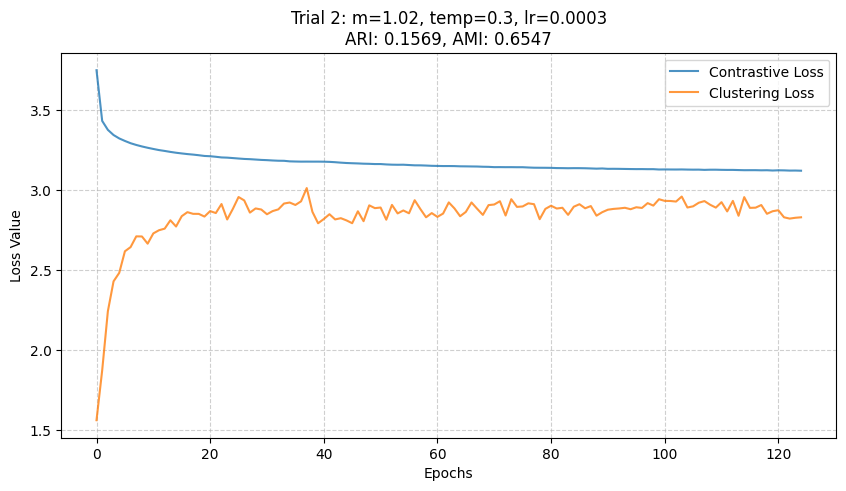

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.1569
AMI: 0.6547
COMBINATION 2: 
HYPERPARAMETERS: {'m': 1.02, 'temp': 0.3, 'lr': 0.0005, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:17<16:18,  9.78s/it]

Epoch [25/125] | Contrastive Loss: 3.1792 | Clustering Loss: 2.9890


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:29<12:46, 10.22s/it]

...

Epoch [75/125] | Contrastive Loss: 3.1338 | Clustering Loss: 2.9004


 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [17:09<04:25, 10.60s/it]

Epoch [100/125] | Contrastive Loss: 3.1234 | Clustering Loss: 2.9610


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [21:21<00:00, 10.25s/it]

Epoch [125/125] | Contrastive Loss: 3.1176 | Clustering Loss: 3.0295


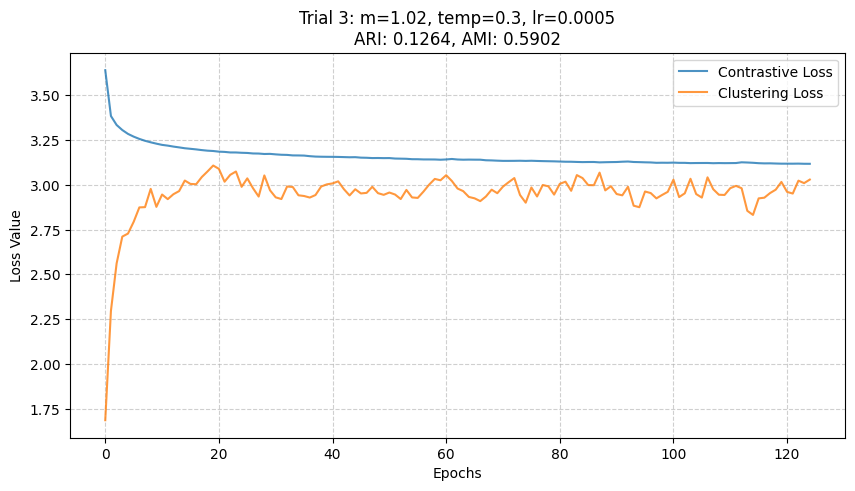

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.1264
AMI: 0.5902
COMBINATION 3: 
HYPERPARAMETERS: {'m': 1.02, 'temp': 0.5, 'lr': 0.0001, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:17<17:31, 10.52s/it]

Epoch [25/125] | Contrastive Loss: 4.3956 | Clustering Loss: 2.3189


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:30<12:49, 10.26s/it]

...

 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [17:07<04:21, 10.46s/it]

Epoch [100/125] | Contrastive Loss: 4.3501 | Clustering Loss: 2.6568


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [21:26<00:00, 10.29s/it]

Epoch [125/125] | Contrastive Loss: 4.3441 | Clustering Loss: 2.5737


NEW BEST ARI!!!


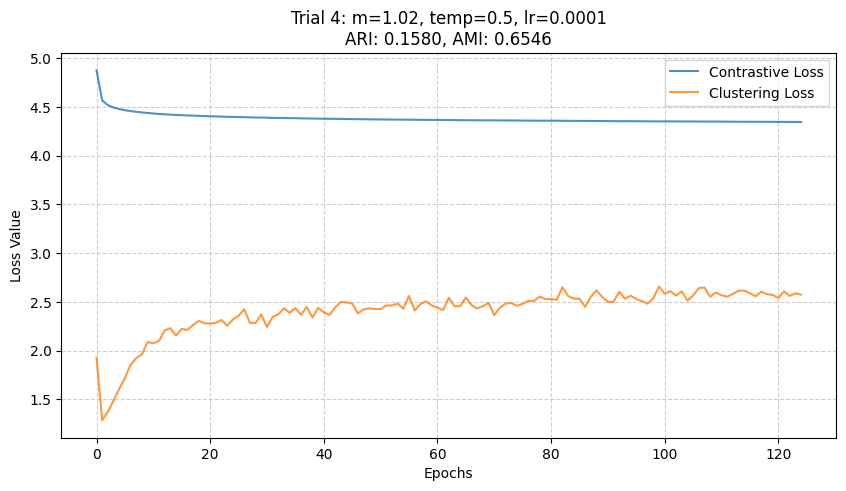

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.1580
AMI: 0.6546
COMBINATION 4: 
HYPERPARAMETERS: {'m': 1.02, 'temp': 0.5, 'lr': 0.0003, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:25<17:05, 10.26s/it]

Epoch [25/125] | Contrastive Loss: 4.3621 | Clustering Loss: 2.7451


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:44<12:46, 10.21s/it]

...

 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [17:20<04:17, 10.29s/it]

Epoch [100/125] | Contrastive Loss: 4.3296 | Clustering Loss: 2.8724


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [21:41<00:00, 10.41s/it]

Epoch [125/125] | Contrastive Loss: 4.3240 | Clustering Loss: 2.8223


NEW BEST ARI!!!


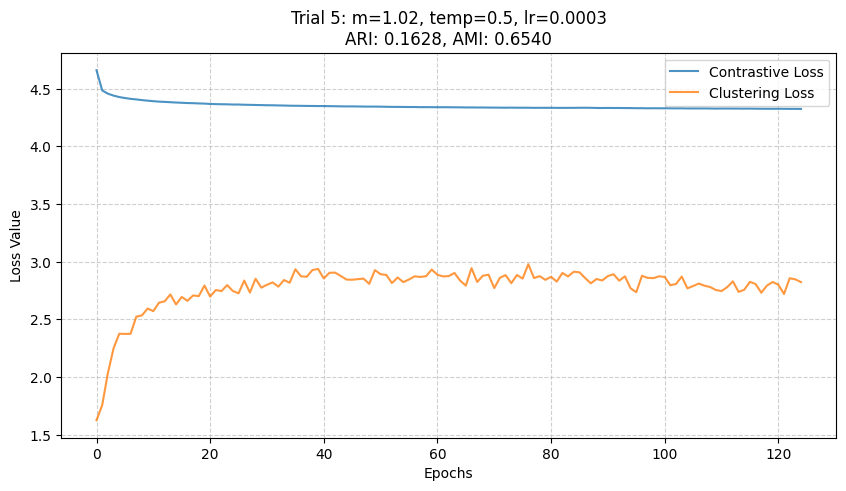

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.1628
AMI: 0.6540
COMBINATION 5: 
HYPERPARAMETERS: {'m': 1.02, 'temp': 0.5, 'lr': 0.0005, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:25<17:26, 10.46s/it]

Epoch [25/125] | Contrastive Loss: 4.3508 | Clustering Loss: 2.9766


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:48<13:08, 10.52s/it]

...

Epoch [75/125] | Contrastive Loss: 4.3309 | Clustering Loss: 2.9348


 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [17:27<04:33, 10.96s/it]

Epoch [100/125] | Contrastive Loss: 4.3276 | Clustering Loss: 2.9175


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [21:49<00:00, 10.47s/it]

Epoch [125/125] | Contrastive Loss: 4.3258 | Clustering Loss: 2.9074


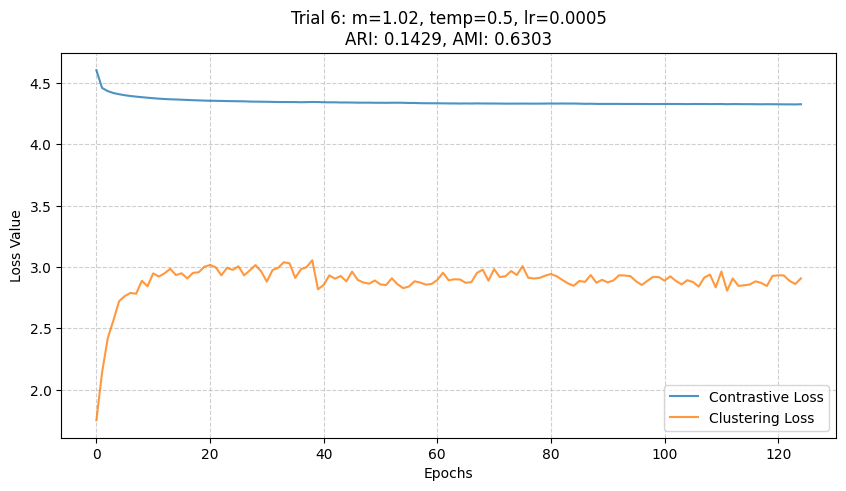

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.1429
AMI: 0.6303
COMBINATION 6: 
HYPERPARAMETERS: {'m': 1.02, 'temp': 0.7, 'lr': 0.0001, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:17<16:48, 10.09s/it]

Epoch [25/125] | Contrastive Loss: 4.9083 | Clustering Loss: 2.1804


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:32<13:01, 10.42s/it]

...

Epoch [75/125] | Contrastive Loss: 4.8833 | Clustering Loss: 2.4318


 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [17:07<04:19, 10.36s/it]

Epoch [100/125] | Contrastive Loss: 4.8770 | Clustering Loss: 2.5109


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [21:23<00:00, 10.27s/it]

Epoch [125/125] | Contrastive Loss: 4.8733 | Clustering Loss: 2.5837


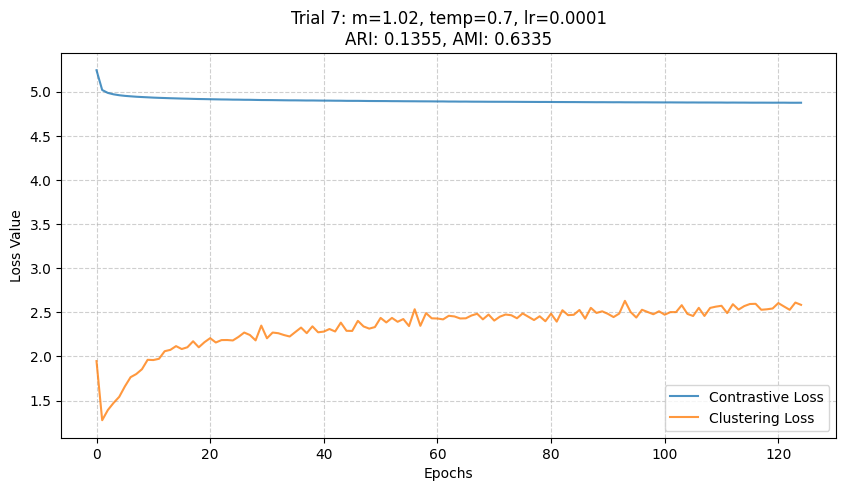

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.1355
AMI: 0.6335
COMBINATION 7: 
HYPERPARAMETERS: {'m': 1.02, 'temp': 0.7, 'lr': 0.0003, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:26<17:34, 10.54s/it]

Epoch [25/125] | Contrastive Loss: 4.8841 | Clustering Loss: 2.7285


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:49<13:12, 10.57s/it]

...

Epoch [75/125] | Contrastive Loss: 4.8670 | Clustering Loss: 2.8976


 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [17:20<04:24, 10.57s/it]

Epoch [100/125] | Contrastive Loss: 4.8646 | Clustering Loss: 2.9089


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [21:27<00:00, 10.30s/it]

Epoch [125/125] | Contrastive Loss: 4.8628 | Clustering Loss: 2.7299


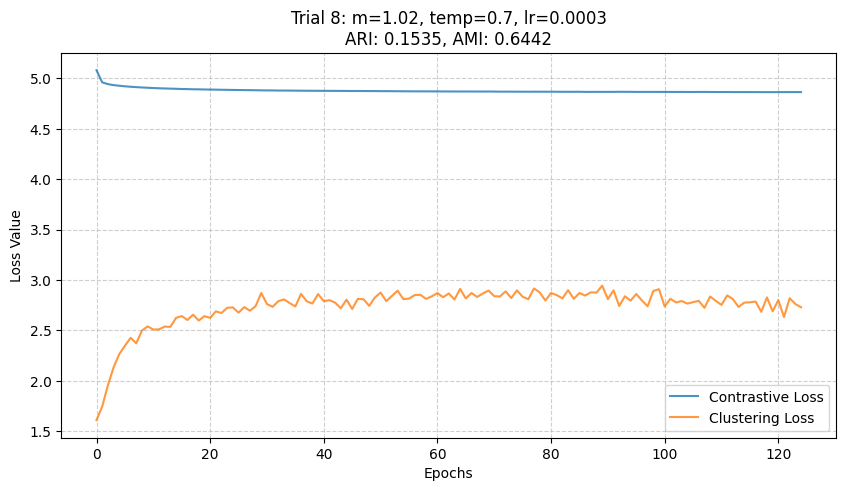

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.1535
AMI: 0.6442
COMBINATION 8: 
HYPERPARAMETERS: {'m': 1.02, 'temp': 0.7, 'lr': 0.0005, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:14<17:27, 10.48s/it]

Epoch [25/125] | Contrastive Loss: 4.8776 | Clustering Loss: 2.9393


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:24<12:57, 10.36s/it]

...

Epoch [75/125] | Contrastive Loss: 4.8669 | Clustering Loss: 2.8716


 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [17:22<04:26, 10.67s/it]

Epoch [100/125] | Contrastive Loss: 4.8667 | Clustering Loss: 2.8298


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [21:47<00:00, 10.46s/it]

Epoch [125/125] | Contrastive Loss: 4.8646 | Clustering Loss: 2.7924


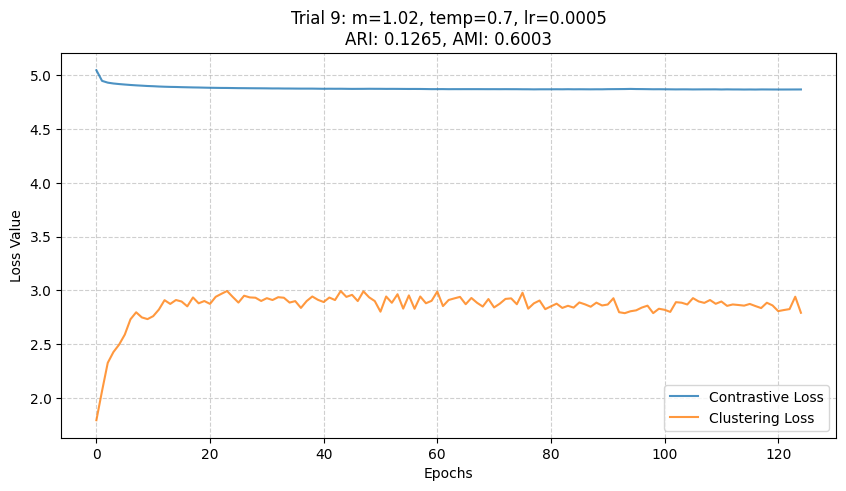

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.1265
AMI: 0.6003
COMBINATION 9: 
HYPERPARAMETERS: {'m': 1.03, 'temp': 0.3, 'lr': 0.0001, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:26<18:15, 10.96s/it]

Epoch [25/125] | Contrastive Loss: 3.2629 | Clustering Loss: 2.0758


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:50<12:51, 10.28s/it]

...

 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [17:41<04:27, 10.70s/it]

Epoch [100/125] | Contrastive Loss: 3.1685 | Clustering Loss: 2.2969


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [21:59<00:00, 10.55s/it]

Epoch [125/125] | Contrastive Loss: 3.1563 | Clustering Loss: 2.2583


NEW BEST AMI!!!


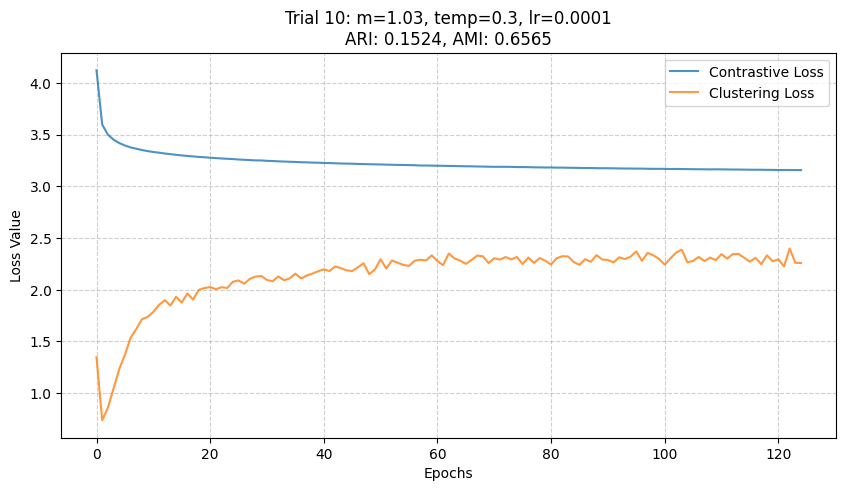

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.1524
AMI: 0.6565
COMBINATION 10: 
HYPERPARAMETERS: {'m': 1.03, 'temp': 0.3, 'lr': 0.0003, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:13<16:28,  9.89s/it]

Epoch [25/125] | Contrastive Loss: 3.1956 | Clustering Loss: 2.5077


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:30<12:50, 10.27s/it]

...

Epoch [75/125] | Contrastive Loss: 3.1398 | Clustering Loss: 2.5750


 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [17:11<04:11, 10.05s/it]

Epoch [100/125] | Contrastive Loss: 3.1302 | Clustering Loss: 2.6010


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [21:32<00:00, 10.34s/it]

Epoch [125/125] | Contrastive Loss: 3.1199 | Clustering Loss: 2.5749


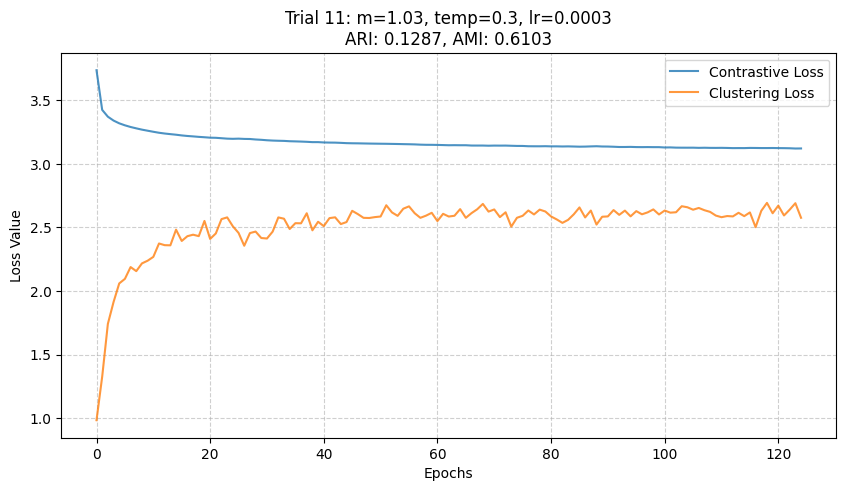

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.1287
AMI: 0.6103
COMBINATION 11: 
HYPERPARAMETERS: {'m': 1.03, 'temp': 0.3, 'lr': 0.0005, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:14<17:23, 10.43s/it]

Epoch [25/125] | Contrastive Loss: 3.1727 | Clustering Loss: 2.7214


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:36<13:18, 10.64s/it]

...

Epoch [75/125] | Contrastive Loss: 3.1243 | Clustering Loss: 2.6273


 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [17:17<04:18, 10.34s/it]

Epoch [100/125] | Contrastive Loss: 3.1146 | Clustering Loss: 2.5505


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [21:38<00:00, 10.39s/it]

Epoch [125/125] | Contrastive Loss: 3.1080 | Clustering Loss: 2.4900


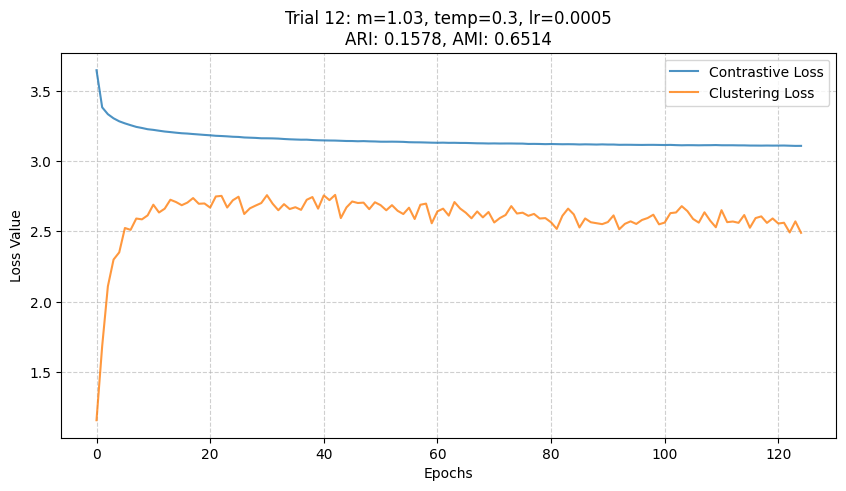

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.1578
AMI: 0.6514
COMBINATION 12: 
HYPERPARAMETERS: {'m': 1.03, 'temp': 0.5, 'lr': 0.0001, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:25<17:32, 10.53s/it]

Epoch [25/125] | Contrastive Loss: 4.3962 | Clustering Loss: 1.9831


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:53<13:32, 10.83s/it]

...

Epoch [75/125] | Contrastive Loss: 4.3587 | Clustering Loss: 2.1303


 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [17:18<03:59,  9.57s/it]

Epoch [100/125] | Contrastive Loss: 4.3492 | Clustering Loss: 2.2505


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [21:31<00:00, 10.33s/it]

Epoch [125/125] | Contrastive Loss: 4.3430 | Clustering Loss: 2.2649


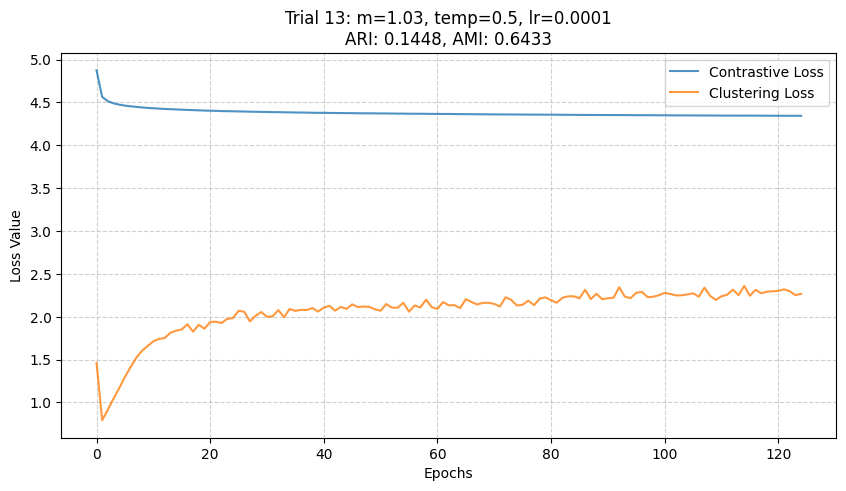

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.1448
AMI: 0.6433
COMBINATION 13: 
HYPERPARAMETERS: {'m': 1.03, 'temp': 0.5, 'lr': 0.0003, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:09<17:33, 10.54s/it]

Epoch [25/125] | Contrastive Loss: 4.3610 | Clustering Loss: 2.3653


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:17<12:59, 10.39s/it]

...

Epoch [75/125] | Contrastive Loss: 4.3375 | Clustering Loss: 2.5072


 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [16:48<04:06,  9.86s/it]

Epoch [100/125] | Contrastive Loss: 4.3268 | Clustering Loss: 2.5935


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [20:56<00:00, 10.05s/it]

Epoch [125/125] | Contrastive Loss: 4.3249 | Clustering Loss: 2.6113


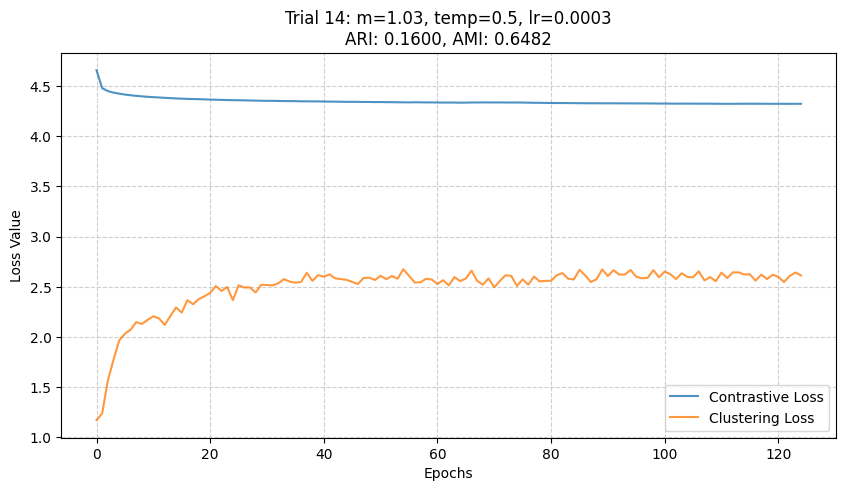

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.1600
AMI: 0.6482
COMBINATION 14: 
HYPERPARAMETERS: {'m': 1.03, 'temp': 0.5, 'lr': 0.0005, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:19<17:15, 10.36s/it]

Epoch [25/125] | Contrastive Loss: 4.3521 | Clustering Loss: 2.6710


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:37<12:48, 10.25s/it]

...

Epoch [75/125] | Contrastive Loss: 4.3332 | Clustering Loss: 2.6804


 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [17:04<04:18, 10.35s/it]

Epoch [100/125] | Contrastive Loss: 4.3284 | Clustering Loss: 2.6454


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [21:30<00:00, 10.33s/it]

Epoch [125/125] | Contrastive Loss: 4.3292 | Clustering Loss: 2.6411


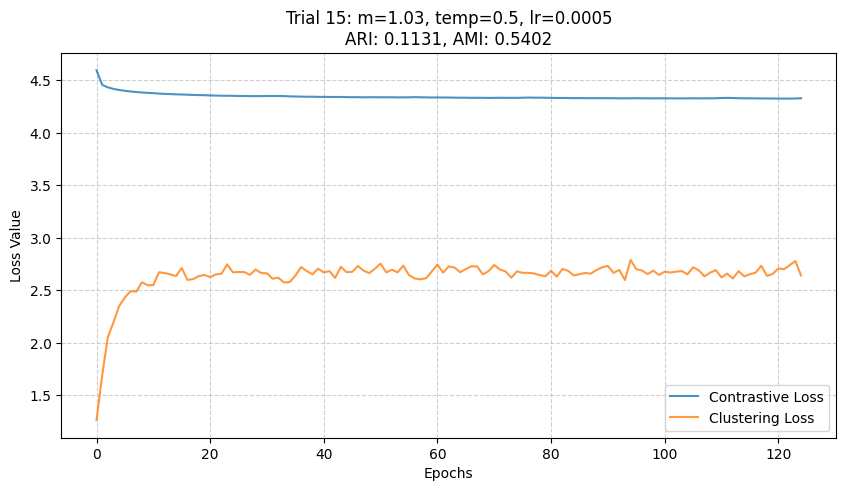

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.1131
AMI: 0.5402
COMBINATION 15: 
HYPERPARAMETERS: {'m': 1.03, 'temp': 0.7, 'lr': 0.0001, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:31<17:45, 10.65s/it]

Epoch [25/125] | Contrastive Loss: 4.9069 | Clustering Loss: 1.9386


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:38<12:48, 10.25s/it]

...

Epoch [75/125] | Contrastive Loss: 4.8821 | Clustering Loss: 2.0799


 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [17:31<04:16, 10.26s/it]

Epoch [100/125] | Contrastive Loss: 4.8755 | Clustering Loss: 2.1450


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [21:46<00:00, 10.45s/it]

Epoch [125/125] | Contrastive Loss: 4.8723 | Clustering Loss: 2.2604


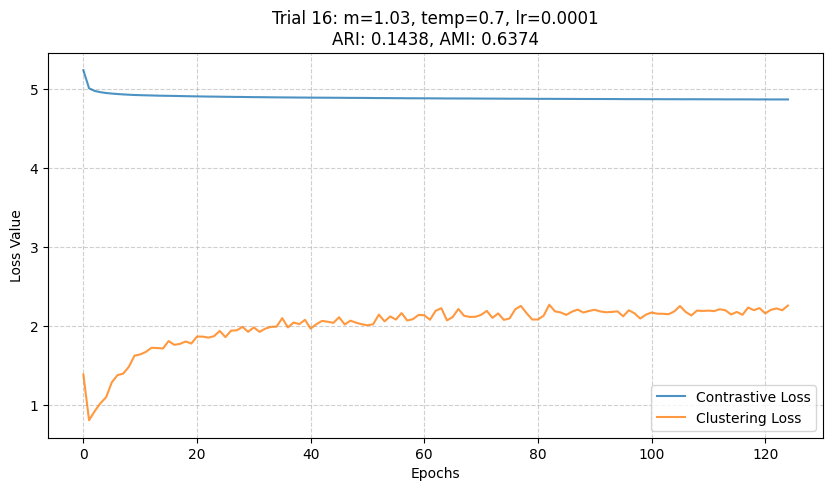

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.1438
AMI: 0.6374
COMBINATION 16: 
HYPERPARAMETERS: {'m': 1.03, 'temp': 0.7, 'lr': 0.0003, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:12<17:01, 10.21s/it]

Epoch [25/125] | Contrastive Loss: 4.8829 | Clustering Loss: 2.3964


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:37<12:57, 10.36s/it]

...

Epoch [75/125] | Contrastive Loss: 4.8669 | Clustering Loss: 2.5372


 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [16:59<03:59,  9.58s/it]

Epoch [100/125] | Contrastive Loss: 4.8637 | Clustering Loss: 2.4715


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [21:15<00:00, 10.20s/it]

Epoch [125/125] | Contrastive Loss: 4.8628 | Clustering Loss: 2.5463


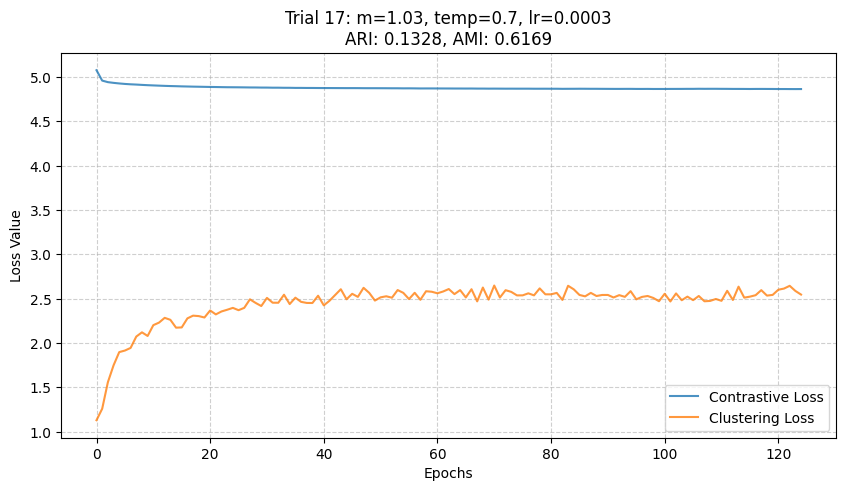

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.1328
AMI: 0.6169
COMBINATION 17: 
HYPERPARAMETERS: {'m': 1.03, 'temp': 0.7, 'lr': 0.0005, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:23<18:06, 10.87s/it]

Epoch [25/125] | Contrastive Loss: 4.8765 | Clustering Loss: 2.6506


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:37<12:19,  9.86s/it]

...

Epoch [75/125] | Contrastive Loss: 4.8665 | Clustering Loss: 2.5462


 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [17:18<04:34, 10.99s/it]

Epoch [100/125] | Contrastive Loss: 4.8642 | Clustering Loss: 2.6520


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [21:33<00:00, 10.35s/it]

Epoch [125/125] | Contrastive Loss: 4.8630 | Clustering Loss: 2.4992


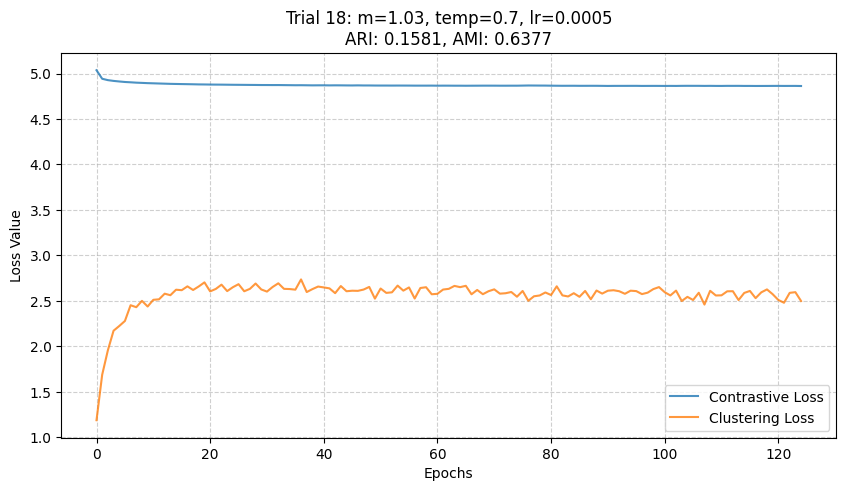

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.1581
AMI: 0.6377
COMBINATION 18: 
HYPERPARAMETERS: {'m': 1.05, 'temp': 0.3, 'lr': 0.0001, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:20<17:35, 10.55s/it]

Epoch [25/125] | Contrastive Loss: 3.2528 | Clustering Loss: 1.2183


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:29<11:50,  9.47s/it]

...

Epoch [75/125] | Contrastive Loss: 3.1764 | Clustering Loss: 1.5273


 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [17:12<04:17, 10.30s/it]

Epoch [100/125] | Contrastive Loss: 3.1587 | Clustering Loss: 1.5160


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [21:38<00:00, 10.39s/it]

Epoch [125/125] | Contrastive Loss: 3.1477 | Clustering Loss: 1.5602


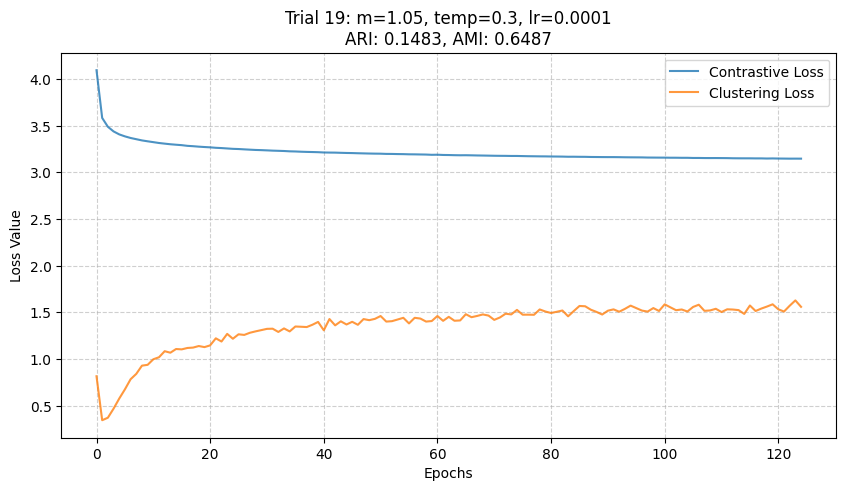

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.1483
AMI: 0.6487
COMBINATION 19: 
HYPERPARAMETERS: {'m': 1.05, 'temp': 0.3, 'lr': 0.0003, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:18<17:45, 10.66s/it]

Epoch [25/125] | Contrastive Loss: 3.1869 | Clustering Loss: 1.7718


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:37<12:42, 10.17s/it]

...

 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [16:50<04:11, 10.04s/it]

Epoch [100/125] | Contrastive Loss: 3.1187 | Clustering Loss: 1.7940


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [21:00<00:00, 10.09s/it]

Epoch [125/125] | Contrastive Loss: 3.1115 | Clustering Loss: 1.6955


NEW BEST ARI!!!
NEW BEST AMI!!!


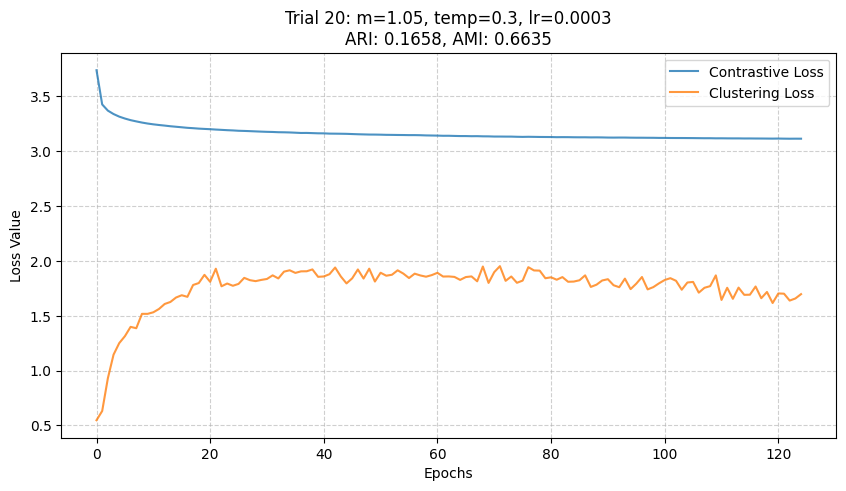

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.1658
AMI: 0.6635
COMBINATION 20: 
HYPERPARAMETERS: {'m': 1.05, 'temp': 0.3, 'lr': 0.0005, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:10<16:43, 10.03s/it]

Epoch [25/125] | Contrastive Loss: 3.1672 | Clustering Loss: 1.9983


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:21<12:36, 10.08s/it]

...

Epoch [75/125] | Contrastive Loss: 3.1200 | Clustering Loss: 1.9990


 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [16:47<04:19, 10.39s/it]

Epoch [100/125] | Contrastive Loss: 3.1144 | Clustering Loss: 1.9338


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [21:07<00:00, 10.14s/it]

Epoch [125/125] | Contrastive Loss: 3.1083 | Clustering Loss: 1.8085


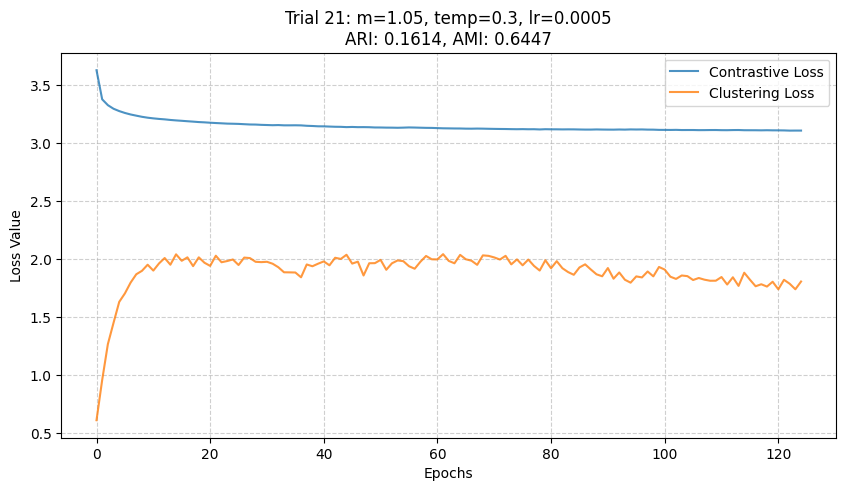

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.1614
AMI: 0.6447
COMBINATION 21: 
HYPERPARAMETERS: {'m': 1.05, 'temp': 0.5, 'lr': 0.0001, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:19<16:15,  9.75s/it]

Epoch [25/125] | Contrastive Loss: 4.3911 | Clustering Loss: 1.2577


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:31<13:24, 10.72s/it]

...

Epoch [75/125] | Contrastive Loss: 4.3530 | Clustering Loss: 1.5341


 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [17:03<04:17, 10.30s/it]

Epoch [100/125] | Contrastive Loss: 4.3446 | Clustering Loss: 1.5431


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [21:23<00:00, 10.27s/it]

Epoch [125/125] | Contrastive Loss: 4.3386 | Clustering Loss: 1.5745


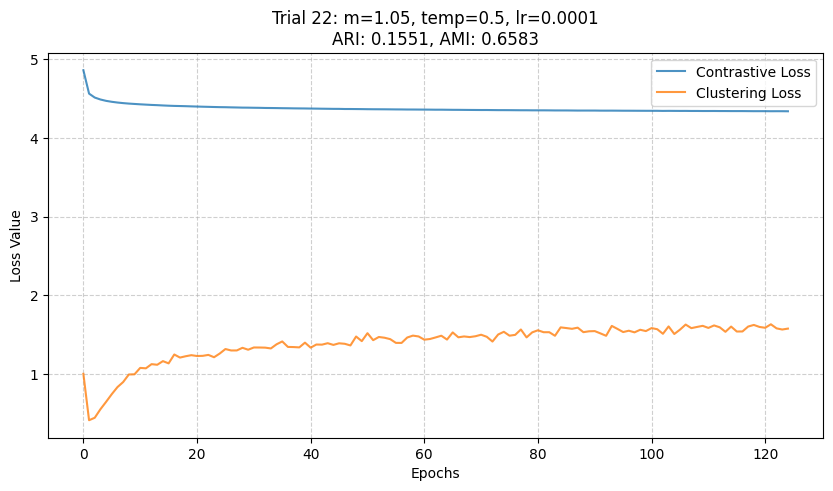

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.1551
AMI: 0.6583
COMBINATION 22: 
HYPERPARAMETERS: {'m': 1.05, 'temp': 0.5, 'lr': 0.0003, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:09<17:43, 10.63s/it]

Epoch [25/125] | Contrastive Loss: 4.3570 | Clustering Loss: 1.8382


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:28<13:14, 10.59s/it]

...

Epoch [75/125] | Contrastive Loss: 4.3313 | Clustering Loss: 1.9270


 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [16:53<04:11, 10.08s/it]

Epoch [100/125] | Contrastive Loss: 4.3279 | Clustering Loss: 1.8973


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [21:11<00:00, 10.17s/it]

Epoch [125/125] | Contrastive Loss: 4.3223 | Clustering Loss: 1.9300


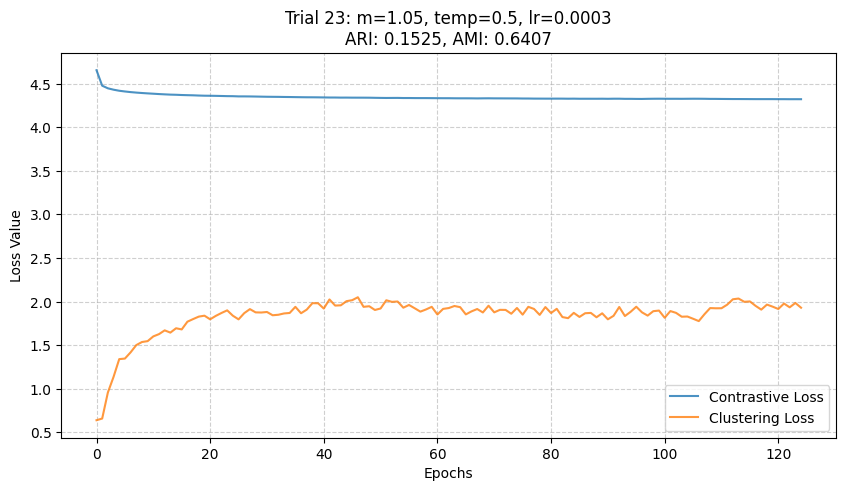

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.1525
AMI: 0.6407
COMBINATION 23: 
HYPERPARAMETERS: {'m': 1.05, 'temp': 0.5, 'lr': 0.0005, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:18<16:51, 10.12s/it]

Epoch [25/125] | Contrastive Loss: 4.3502 | Clustering Loss: 2.0386


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:46<12:50, 10.28s/it]

...

Epoch [75/125] | Contrastive Loss: 4.3290 | Clustering Loss: 2.1299


 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [17:26<04:20, 10.44s/it]

Epoch [100/125] | Contrastive Loss: 4.3259 | Clustering Loss: 2.1583


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [21:46<00:00, 10.45s/it]

Epoch [125/125] | Contrastive Loss: 4.3258 | Clustering Loss: 1.9962


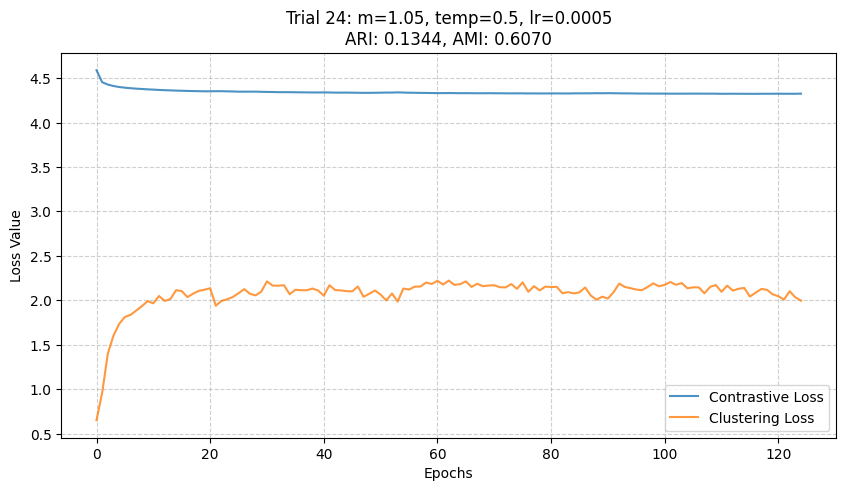

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.1344
AMI: 0.6070
COMBINATION 24: 
HYPERPARAMETERS: {'m': 1.05, 'temp': 0.7, 'lr': 0.0001, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:31<19:07, 11.48s/it]

Epoch [25/125] | Contrastive Loss: 4.9019 | Clustering Loss: 1.3584


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:59<12:52, 10.30s/it]

...

Epoch [75/125] | Contrastive Loss: 4.8784 | Clustering Loss: 1.4650


 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [17:20<04:05,  9.83s/it]

Epoch [100/125] | Contrastive Loss: 4.8728 | Clustering Loss: 1.5909


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [21:30<00:00, 10.33s/it]

Epoch [125/125] | Contrastive Loss: 4.8697 | Clustering Loss: 1.5918


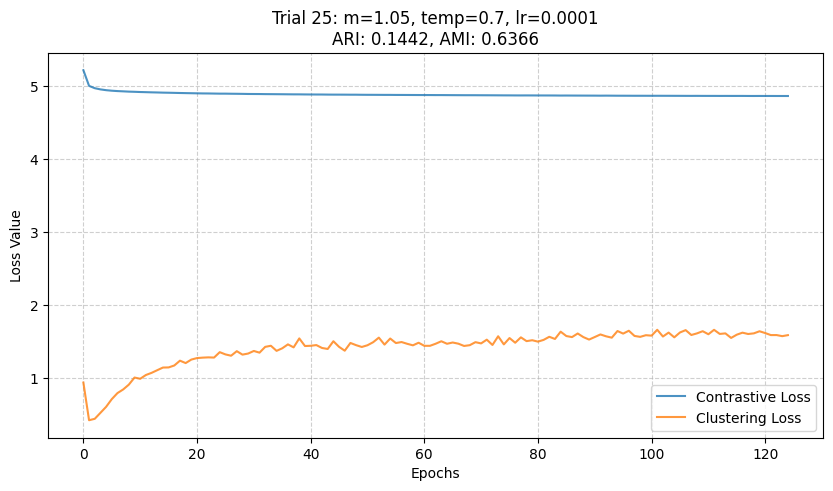

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.1442
AMI: 0.6366
COMBINATION 25: 
HYPERPARAMETERS: {'m': 1.05, 'temp': 0.7, 'lr': 0.0003, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:04<17:15, 10.36s/it]

Epoch [25/125] | Contrastive Loss: 4.8804 | Clustering Loss: 1.9021


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:17<12:36, 10.08s/it]

...

 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [16:38<04:17, 10.31s/it]

Epoch [100/125] | Contrastive Loss: 4.8620 | Clustering Loss: 1.8745


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [20:46<00:00,  9.97s/it]

Epoch [125/125] | Contrastive Loss: 4.8605 | Clustering Loss: 1.8449


NEW BEST ARI!!!


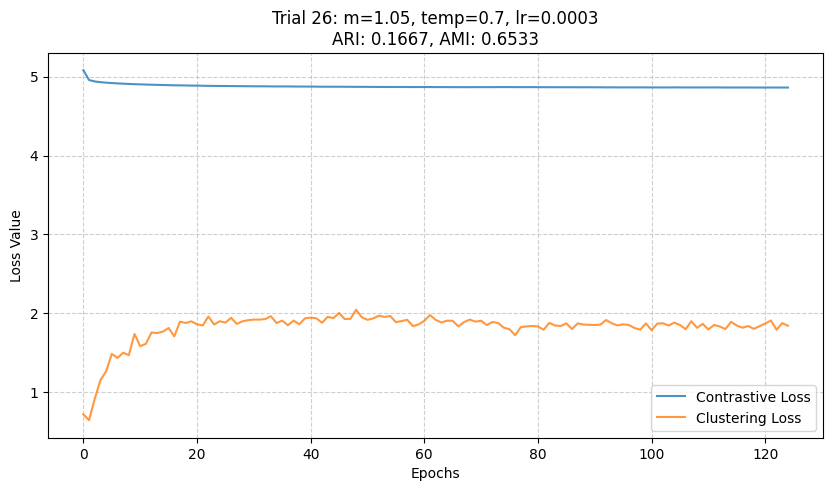

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.1667
AMI: 0.6533
COMBINATION 26: 
HYPERPARAMETERS: {'m': 1.05, 'temp': 0.7, 'lr': 0.0005, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:11<16:00,  9.60s/it]

Epoch [25/125] | Contrastive Loss: 4.8751 | Clustering Loss: 2.0326


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:29<12:32, 10.03s/it]

...

Epoch [75/125] | Contrastive Loss: 4.8643 | Clustering Loss: 1.9253


 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [16:51<04:15, 10.22s/it]

Epoch [100/125] | Contrastive Loss: 4.8624 | Clustering Loss: 1.9348


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [20:56<00:00, 10.05s/it]

Epoch [125/125] | Contrastive Loss: 4.8623 | Clustering Loss: 1.8918


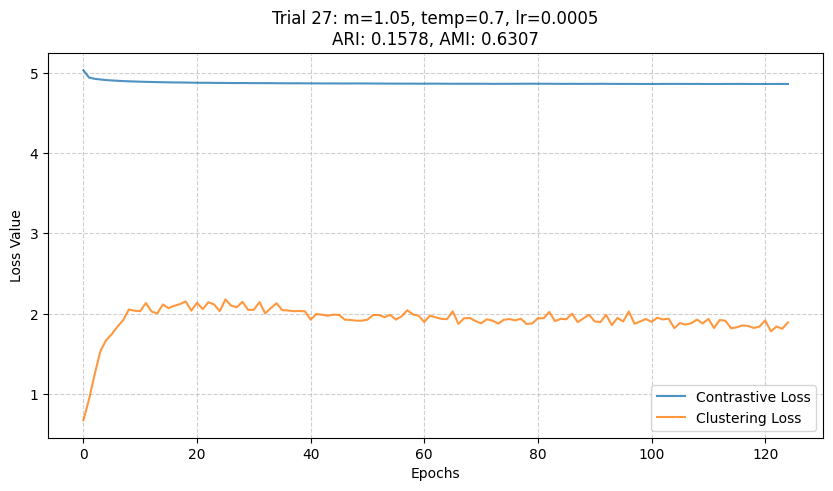

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.1578
AMI: 0.6307
COMBINATION 27: 
HYPERPARAMETERS: {'m': 1.07, 'temp': 0.3, 'lr': 0.0001, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:09<17:37, 10.57s/it]

Epoch [25/125] | Contrastive Loss: 3.2424 | Clustering Loss: 0.7070


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:19<12:38, 10.12s/it]

...

Epoch [75/125] | Contrastive Loss: 3.1662 | Clustering Loss: 0.7843


 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [16:59<04:11, 10.06s/it]

Epoch [100/125] | Contrastive Loss: 3.1523 | Clustering Loss: 0.8950


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [21:25<00:00, 10.28s/it]

Epoch [125/125] | Contrastive Loss: 3.1416 | Clustering Loss: 0.9196


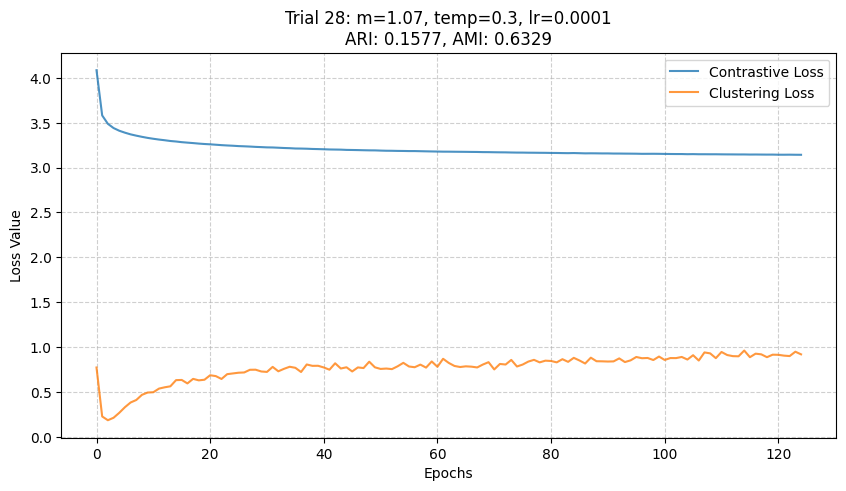

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.1577
AMI: 0.6329
COMBINATION 28: 
HYPERPARAMETERS: {'m': 1.07, 'temp': 0.3, 'lr': 0.0003, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:27<18:12, 10.92s/it]

Epoch [25/125] | Contrastive Loss: 3.1816 | Clustering Loss: 1.0581


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:31<11:35,  9.28s/it]

...

Epoch [75/125] | Contrastive Loss: 3.1266 | Clustering Loss: 1.2982


 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [16:29<04:06,  9.87s/it]

Epoch [100/125] | Contrastive Loss: 3.1154 | Clustering Loss: 1.1376


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [20:39<00:00,  9.92s/it]

Epoch [125/125] | Contrastive Loss: 3.1074 | Clustering Loss: 1.0261


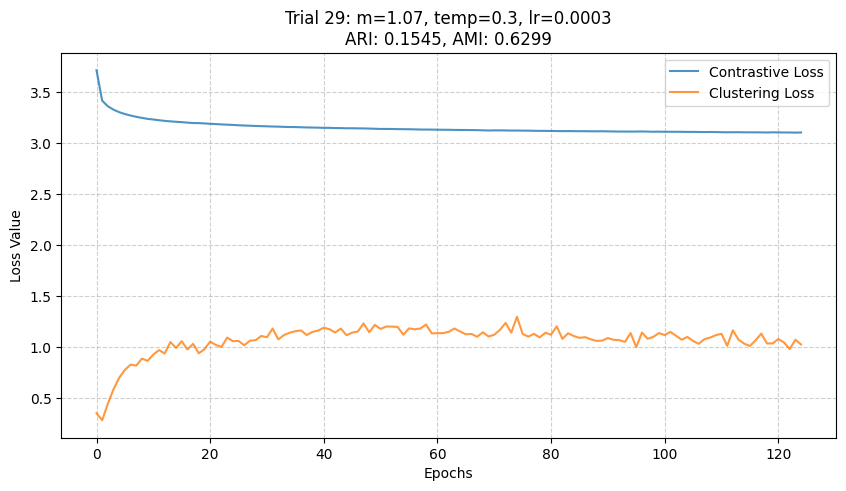

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.1545
AMI: 0.6299
COMBINATION 29: 
HYPERPARAMETERS: {'m': 1.07, 'temp': 0.3, 'lr': 0.0005, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:19<17:38, 10.59s/it]

Epoch [25/125] | Contrastive Loss: 3.1611 | Clustering Loss: 1.3156


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:36<12:44, 10.19s/it]

...

Epoch [75/125] | Contrastive Loss: 3.1173 | Clustering Loss: 1.0774


 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [16:57<04:02,  9.69s/it]

Epoch [100/125] | Contrastive Loss: 3.1093 | Clustering Loss: 1.0188


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [21:06<00:00, 10.13s/it]

Epoch [125/125] | Contrastive Loss: 3.1043 | Clustering Loss: 1.0000


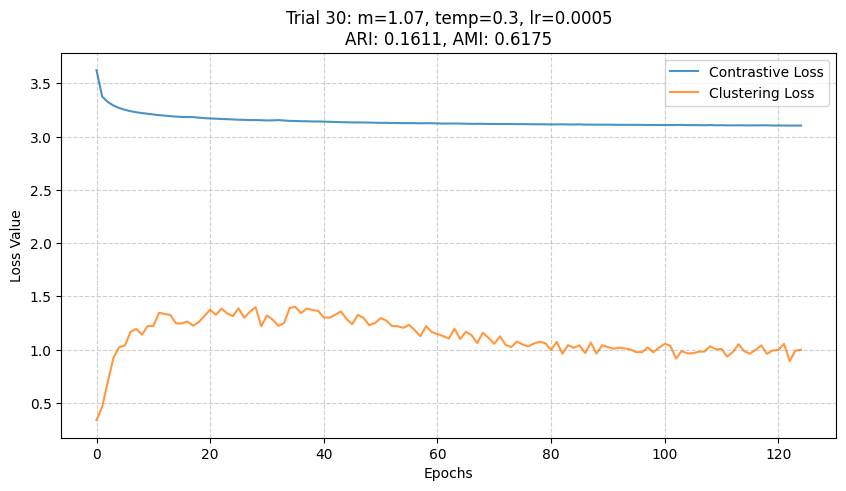

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.1611
AMI: 0.6175
COMBINATION 30: 
HYPERPARAMETERS: {'m': 1.07, 'temp': 0.5, 'lr': 0.0001, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:10<16:35,  9.96s/it]

Epoch [25/125] | Contrastive Loss: 4.3854 | Clustering Loss: 0.7810


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:31<12:54, 10.33s/it]

...

Epoch [75/125] | Contrastive Loss: 4.3473 | Clustering Loss: 0.9407


 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [16:52<04:13, 10.15s/it]

Epoch [100/125] | Contrastive Loss: 4.3398 | Clustering Loss: 1.0098


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [21:09<00:00, 10.16s/it]

Epoch [125/125] | Contrastive Loss: 4.3346 | Clustering Loss: 0.9541


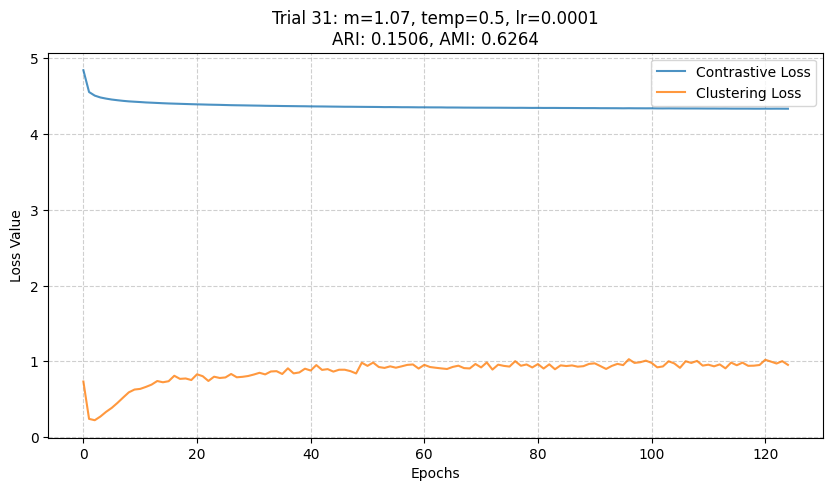

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.1506
AMI: 0.6264
COMBINATION 31: 
HYPERPARAMETERS: {'m': 1.07, 'temp': 0.5, 'lr': 0.0003, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:10<16:26,  9.86s/it]

Epoch [25/125] | Contrastive Loss: 4.3573 | Clustering Loss: 1.2157


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:28<12:50, 10.28s/it]

...

Epoch [75/125] | Contrastive Loss: 4.3295 | Clustering Loss: 1.4309


 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [17:06<04:11, 10.07s/it]

Epoch [100/125] | Contrastive Loss: 4.3246 | Clustering Loss: 1.4332


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [21:20<00:00, 10.25s/it]

Epoch [125/125] | Contrastive Loss: 4.3210 | Clustering Loss: 1.3338


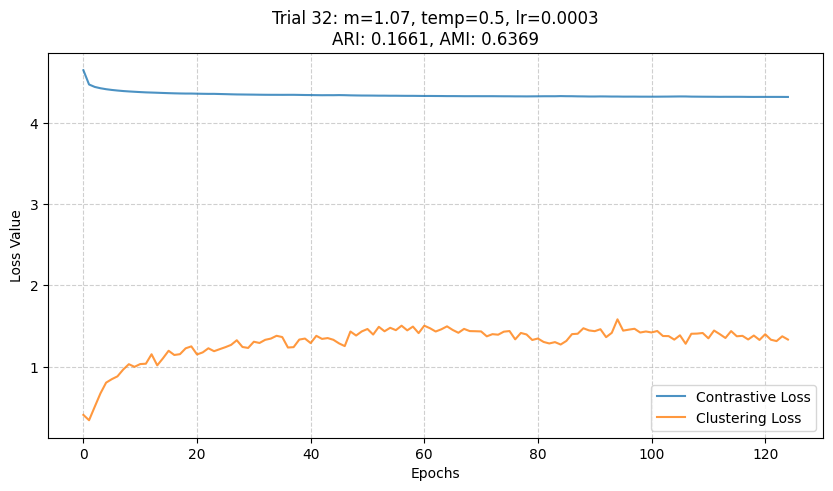

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.1661
AMI: 0.6369
COMBINATION 32: 
HYPERPARAMETERS: {'m': 1.07, 'temp': 0.5, 'lr': 0.0005, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:21<17:18, 10.38s/it]

Epoch [25/125] | Contrastive Loss: 4.3448 | Clustering Loss: 1.5213


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:37<11:42,  9.37s/it]

...

 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [17:21<04:36, 11.07s/it]

Epoch [100/125] | Contrastive Loss: 4.3233 | Clustering Loss: 1.2473


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [21:49<00:00, 10.48s/it]

Epoch [125/125] | Contrastive Loss: 4.3218 | Clustering Loss: 1.0733


NEW BEST ARI!!!


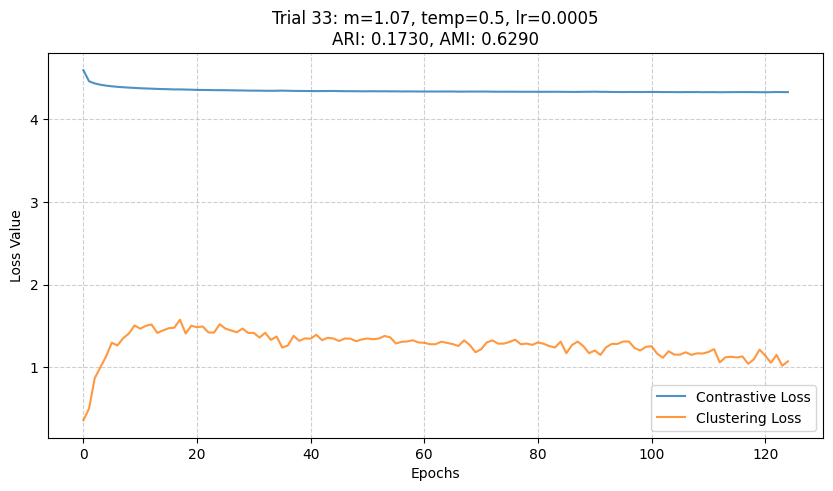

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.1730
AMI: 0.6290
COMBINATION 33: 
HYPERPARAMETERS: {'m': 1.07, 'temp': 0.7, 'lr': 0.0001, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:21<17:34, 10.55s/it]

Epoch [25/125] | Contrastive Loss: 4.9010 | Clustering Loss: 0.8284


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:52<13:15, 10.61s/it]

...

Epoch [75/125] | Contrastive Loss: 4.8763 | Clustering Loss: 1.0003


 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [17:34<04:30, 10.81s/it]

Epoch [100/125] | Contrastive Loss: 4.8712 | Clustering Loss: 1.0621


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [21:59<00:00, 10.55s/it]

Epoch [125/125] | Contrastive Loss: 4.8677 | Clustering Loss: 1.0951


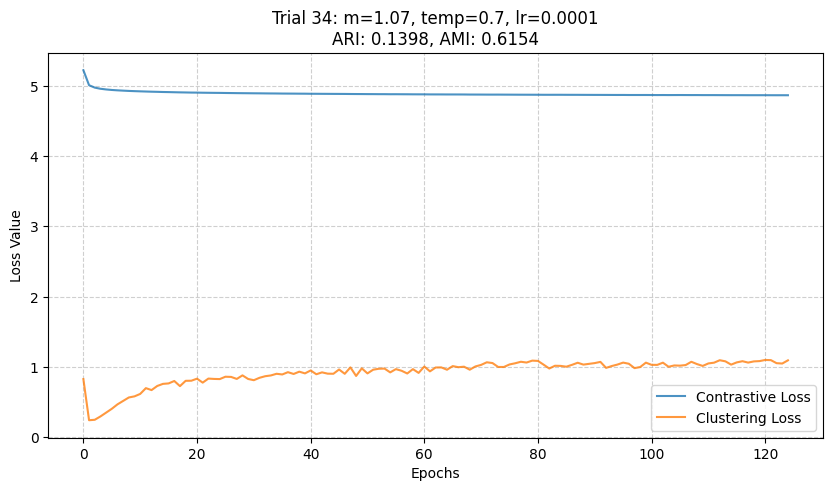

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.1398
AMI: 0.6154
COMBINATION 34: 
HYPERPARAMETERS: {'m': 1.07, 'temp': 0.7, 'lr': 0.0003, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:31<17:59, 10.80s/it]

Epoch [25/125] | Contrastive Loss: 4.8790 | Clustering Loss: 1.3320


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:37<12:22,  9.90s/it]

...

Epoch [75/125] | Contrastive Loss: 4.8639 | Clustering Loss: 1.2622


 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [17:01<04:18, 10.33s/it]

Epoch [100/125] | Contrastive Loss: 4.8606 | Clustering Loss: 1.2887


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [21:12<00:00, 10.18s/it]

Epoch [125/125] | Contrastive Loss: 4.8592 | Clustering Loss: 1.1698


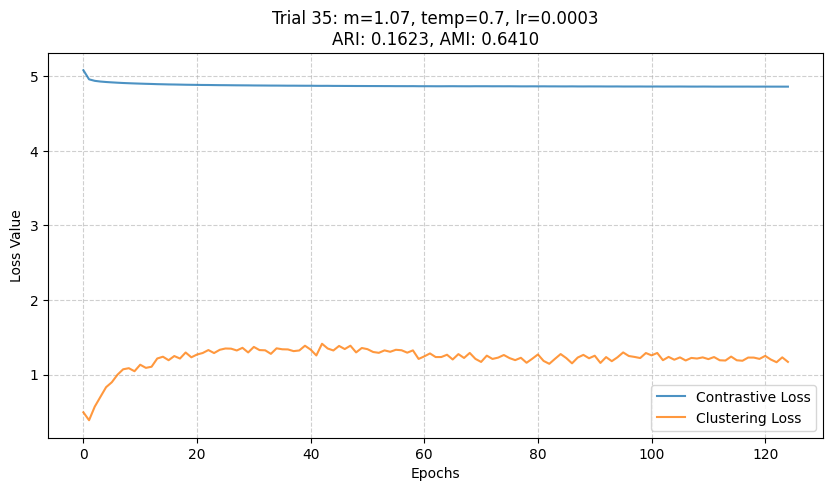

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.1623
AMI: 0.6410
COMBINATION 35: 
HYPERPARAMETERS: {'m': 1.07, 'temp': 0.7, 'lr': 0.0005, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:15<16:49, 10.10s/it]

Epoch [25/125] | Contrastive Loss: 4.8737 | Clustering Loss: 1.5124


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:47<13:13, 10.58s/it]

...

Epoch [75/125] | Contrastive Loss: 4.8647 | Clustering Loss: 1.4208


 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [17:47<04:18, 10.32s/it]

Epoch [100/125] | Contrastive Loss: 4.8634 | Clustering Loss: 1.6321


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [22:06<00:00, 10.62s/it]

Epoch [125/125] | Contrastive Loss: 4.8623 | Clustering Loss: 1.4969


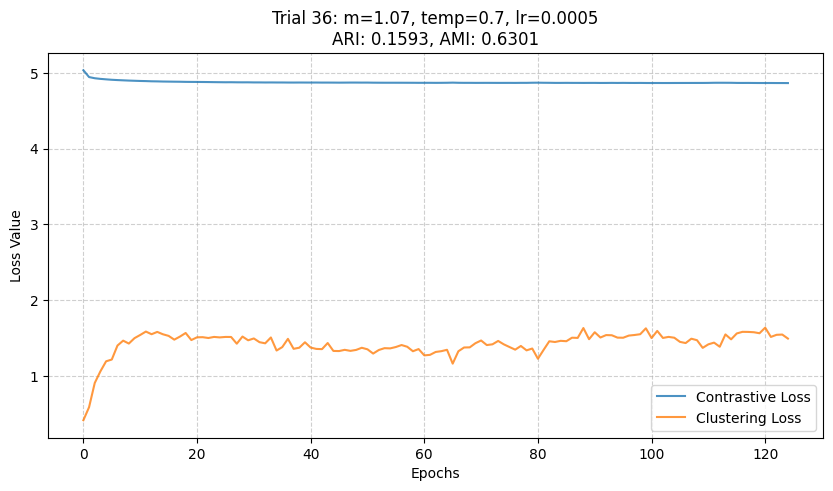

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.1593
AMI: 0.6301
COMBINATION 36: 
HYPERPARAMETERS: {'m': 1.1, 'temp': 0.3, 'lr': 0.0001, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:15<16:52, 10.13s/it]

Epoch [25/125] | Contrastive Loss: 3.2305 | Clustering Loss: 0.2569


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:25<12:31, 10.02s/it]

...

Epoch [75/125] | Contrastive Loss: 3.1545 | Clustering Loss: 0.3965


 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [16:57<04:20, 10.41s/it]

Epoch [100/125] | Contrastive Loss: 3.1400 | Clustering Loss: 0.3559


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [21:13<00:00, 10.19s/it]

Epoch [125/125] | Contrastive Loss: 3.1311 | Clustering Loss: 0.3969


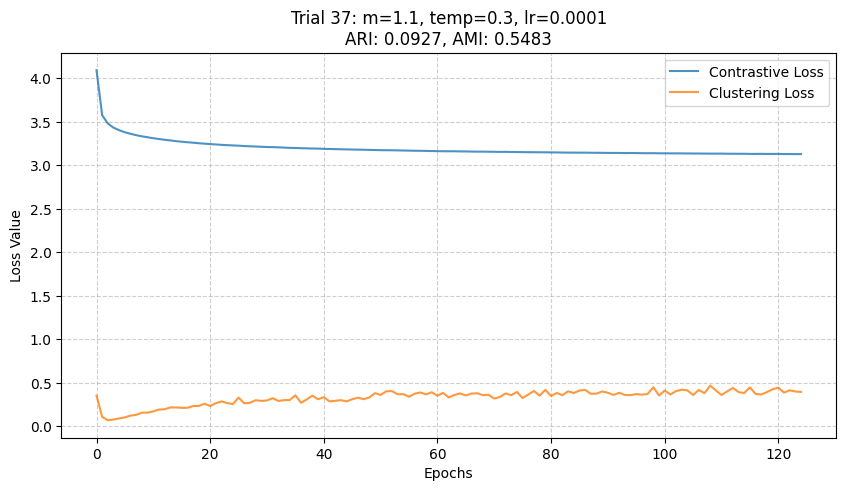

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.0927
AMI: 0.5483
COMBINATION 37: 
HYPERPARAMETERS: {'m': 1.1, 'temp': 0.3, 'lr': 0.0003, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:09<16:41, 10.02s/it]

Epoch [25/125] | Contrastive Loss: 3.1677 | Clustering Loss: 0.4758


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:23<12:29,  9.99s/it]

...

Epoch [75/125] | Contrastive Loss: 3.1152 | Clustering Loss: 0.4682


 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [16:50<04:17, 10.30s/it]

Epoch [100/125] | Contrastive Loss: 3.1043 | Clustering Loss: 0.3839


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [21:05<00:00, 10.13s/it]

Epoch [125/125] | Contrastive Loss: 3.0977 | Clustering Loss: 0.4031


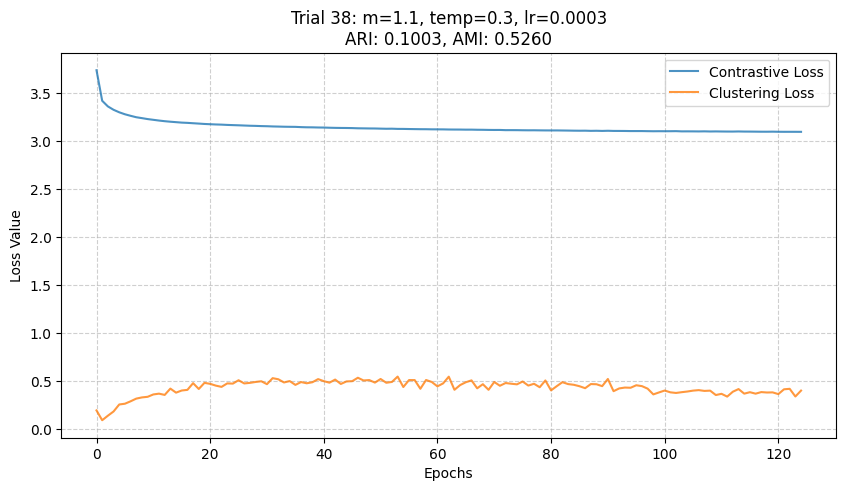

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.1003
AMI: 0.5260
COMBINATION 38: 
HYPERPARAMETERS: {'m': 1.1, 'temp': 0.3, 'lr': 0.0005, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:11<16:35,  9.95s/it]

Epoch [25/125] | Contrastive Loss: 3.1486 | Clustering Loss: 0.4708


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:23<12:39, 10.13s/it]

...

Epoch [75/125] | Contrastive Loss: 3.1027 | Clustering Loss: 0.2625


 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [16:53<04:16, 10.26s/it]

Epoch [100/125] | Contrastive Loss: 3.0953 | Clustering Loss: 0.2188


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [21:12<00:00, 10.18s/it]

Epoch [125/125] | Contrastive Loss: 3.0902 | Clustering Loss: 0.1369


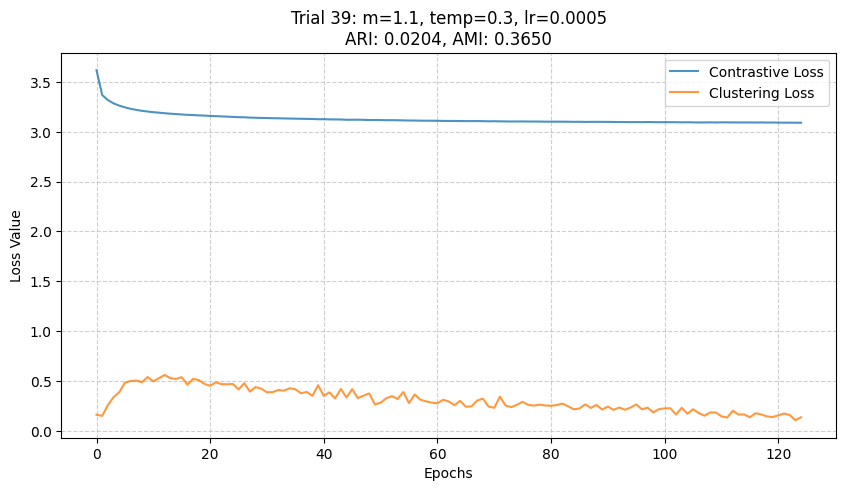

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.0204
AMI: 0.3650
COMBINATION 39: 
HYPERPARAMETERS: {'m': 1.1, 'temp': 0.5, 'lr': 0.0001, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:10<17:23, 10.44s/it]

Epoch [25/125] | Contrastive Loss: 4.3750 | Clustering Loss: 0.3482


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:27<12:27,  9.97s/it]

...

Epoch [75/125] | Contrastive Loss: 4.3406 | Clustering Loss: 0.4401


 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [17:04<04:14, 10.17s/it]

Epoch [100/125] | Contrastive Loss: 4.3334 | Clustering Loss: 0.3966


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [21:24<00:00, 10.27s/it]

Epoch [125/125] | Contrastive Loss: 4.3281 | Clustering Loss: 0.4102


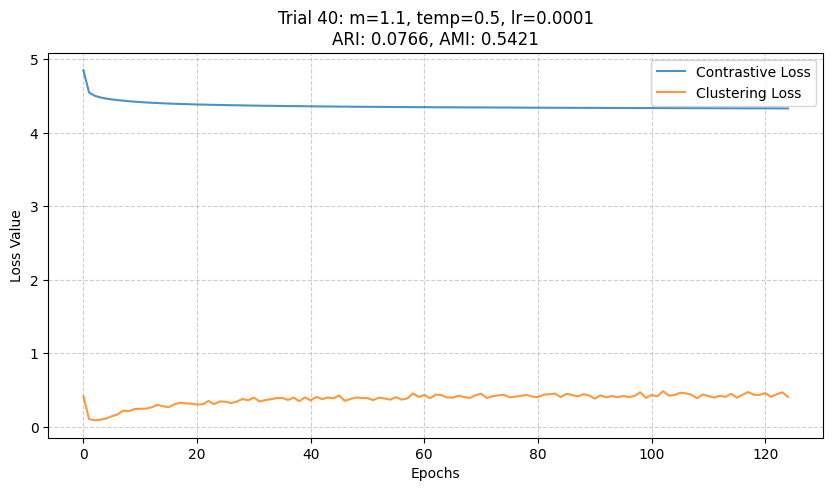

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.0766
AMI: 0.5421
COMBINATION 40: 
HYPERPARAMETERS: {'m': 1.1, 'temp': 0.5, 'lr': 0.0003, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:17<16:55, 10.15s/it]

Epoch [25/125] | Contrastive Loss: 4.3473 | Clustering Loss: 0.6094


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:36<13:17, 10.63s/it]

...

Epoch [75/125] | Contrastive Loss: 4.3226 | Clustering Loss: 0.5773


 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [17:06<04:23, 10.55s/it]

Epoch [100/125] | Contrastive Loss: 4.3178 | Clustering Loss: 0.5588


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [21:32<00:00, 10.34s/it]

Epoch [125/125] | Contrastive Loss: 4.3151 | Clustering Loss: 0.5496


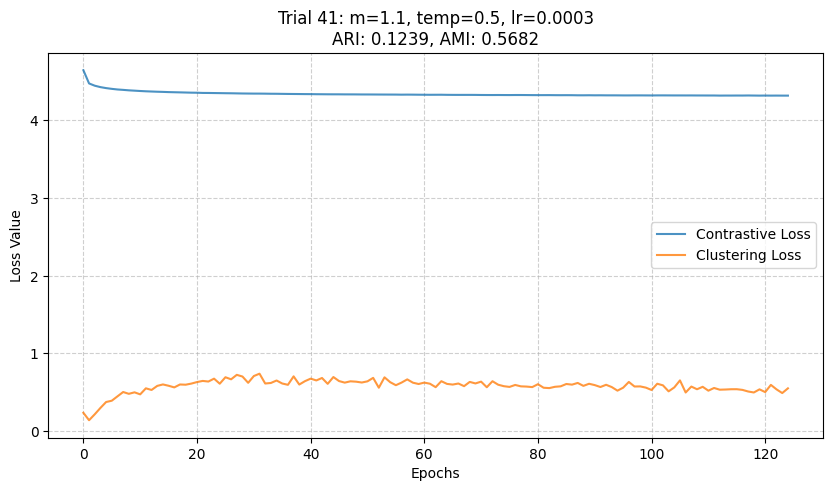

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.1239
AMI: 0.5682
COMBINATION 41: 
HYPERPARAMETERS: {'m': 1.1, 'temp': 0.5, 'lr': 0.0005, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:34<19:22, 11.62s/it]

Epoch [25/125] | Contrastive Loss: 4.3416 | Clustering Loss: 0.8753


 40%|██████████████████████████████████████████▊                                                                | 50/125 [09:17<12:58, 10.38s/it]

...

Epoch [75/125] | Contrastive Loss: 4.3208 | Clustering Loss: 0.5023


 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [17:45<04:09,  9.99s/it]

Epoch [100/125] | Contrastive Loss: 4.3172 | Clustering Loss: 0.4285


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [22:01<00:00, 10.58s/it]

Epoch [125/125] | Contrastive Loss: 4.3166 | Clustering Loss: 0.4647


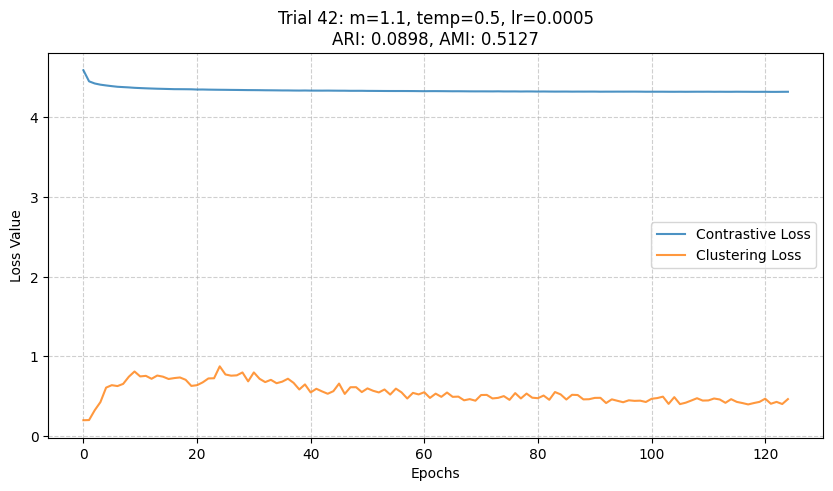

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.0898
AMI: 0.5127
COMBINATION 42: 
HYPERPARAMETERS: {'m': 1.1, 'temp': 0.7, 'lr': 0.0001, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:10<16:07,  9.68s/it]

Epoch [25/125] | Contrastive Loss: 4.8957 | Clustering Loss: 0.4023


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:23<12:36, 10.09s/it]

...

Epoch [75/125] | Contrastive Loss: 4.8718 | Clustering Loss: 0.5644


 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [16:40<04:06,  9.87s/it]

Epoch [100/125] | Contrastive Loss: 4.8670 | Clustering Loss: 0.5354


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [21:00<00:00, 10.08s/it]

Epoch [125/125] | Contrastive Loss: 4.8645 | Clustering Loss: 0.5777


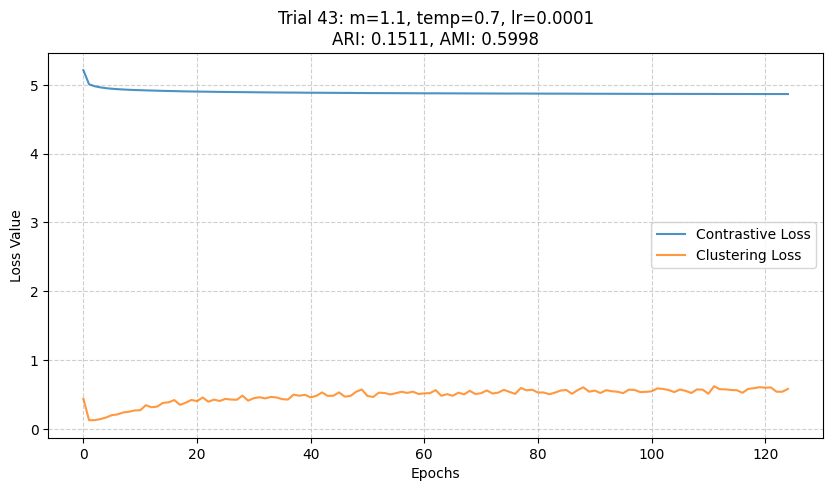

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.1511
AMI: 0.5998
COMBINATION 43: 
HYPERPARAMETERS: {'m': 1.1, 'temp': 0.7, 'lr': 0.0003, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:23<17:55, 10.75s/it]

Epoch [25/125] | Contrastive Loss: 4.8751 | Clustering Loss: 0.6266


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:46<13:05, 10.47s/it]

...

Epoch [75/125] | Contrastive Loss: 4.8611 | Clustering Loss: 0.6556


 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [17:21<04:12, 10.12s/it]

Epoch [100/125] | Contrastive Loss: 4.8586 | Clustering Loss: 0.6232


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [21:26<00:00, 10.29s/it]

Epoch [125/125] | Contrastive Loss: 4.8579 | Clustering Loss: 0.6404


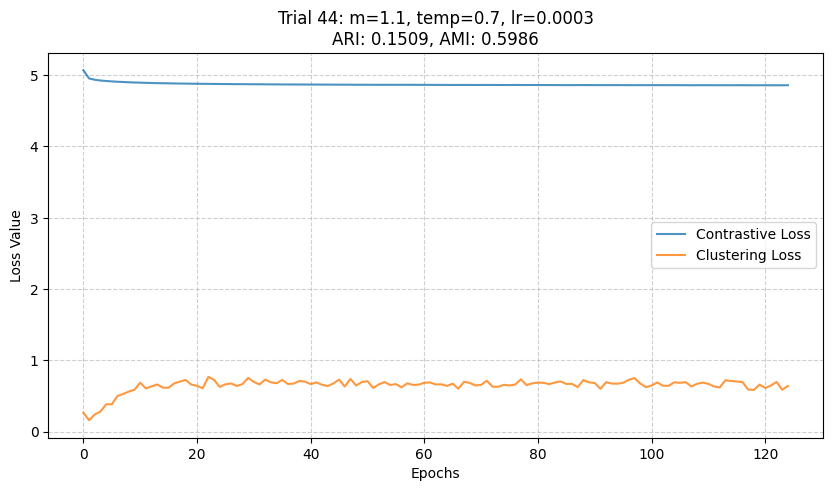

/tmp/ipykernel_1478292/1046492140.py:26: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


ARI: 0.1509
AMI: 0.5986
COMBINATION 44: 
HYPERPARAMETERS: {'m': 1.1, 'temp': 0.7, 'lr': 0.0005, 'wd': 0.0001}


 20%|█████████████████████▍                                                                                     | 25/125 [04:11<17:00, 10.21s/it]

Epoch [25/125] | Contrastive Loss: 4.8725 | Clustering Loss: 0.9253


 40%|██████████████████████████████████████████▊                                                                | 50/125 [08:24<12:58, 10.39s/it]

...

Epoch [75/125] | Contrastive Loss: 4.8638 | Clustering Loss: 0.8203


 80%|████████████████████████████████████████████████████████████████████████████████████▊                     | 100/125 [16:48<04:14, 10.18s/it]

Epoch [100/125] | Contrastive Loss: 4.8651 | Clustering Loss: 0.7740


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 125/125 [21:02<00:00, 10.10s/it]

Epoch [125/125] | Contrastive Loss: 4.8611 | Clustering Loss: 0.8607


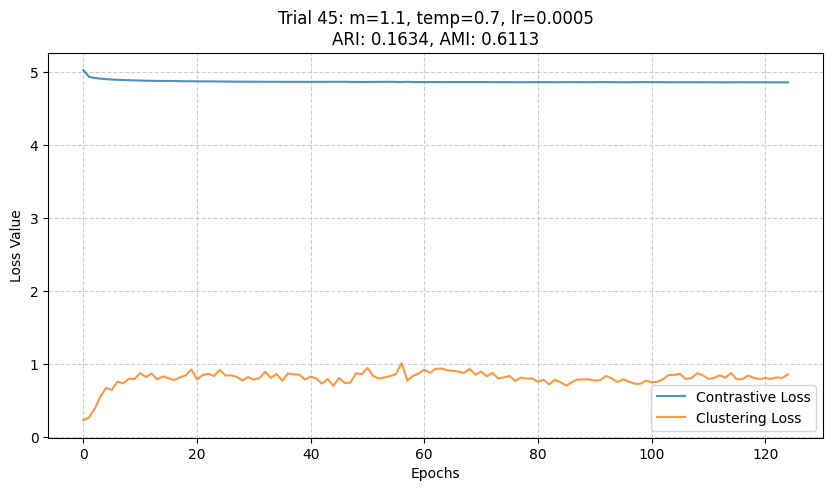

ARI: 0.1634
AMI: 0.6113
DONE!!!


In [14]:
num_combos = len(combinations)
# ground truth labels from metadata
y_true = metadata['label'].values

best_ari = -1.0
best_ami = -1.0
results = []
epochs = 125

print("HP Tuning started")
start_time = time.time()
for i in range(num_combos):
    print(f"COMBINATION {i}: ")
    hps = combinations[i]
    print(f"HYPERPARAMETERS: {hps}")
    history = {
        'contrastive': [],
        'clustering': []
    }

    # Init model, optimizer, loss, and scaler
    my_backbone = TwitterBackbone(input_dim=input_dim, rep_dim=feature_dim)
    model = Network(my_backbone, my_backbone.rep_dim, class_dim=num_events).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=hps['lr'], weight_decay=hps['wd'])
    criterion = InfonceLoss(batch_size=batch_size, temperature=hps['temp'], device=device).to(device)
    scaler = torch.cuda.amp.GradScaler()

    # TRAINING LOOP
    for epoch in tqdm(range(epochs)):
        # Run 1 full pass thru Twitter data
        losses = train_model(model, ins_loader, optimizer, criterion, scaler, device, m=hps["m"])
        history['contrastive'].append(losses['loss1'])
        history['clustering'].append(losses['loss2'])
        
        # Print progress every 25 epochs
        if (epoch + 1) % 25 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Contrastive Loss: {losses['loss1']:.4f} | Clustering Loss: {losses['loss2']:.4f}")
    # Training is DONE
    
    # EVALUATION
    model.eval()
    with torch.no_grad():
        # Clustering
        _, probs = model.test_forward(embeddings)
        preds = torch.argmax(probs, dim=1).cpu().numpy()

    # Calculate Metrics
    ari = adjusted_rand_score(y_true, preds)
    ami = adjusted_mutual_info_score(y_true, preds)

    # Save Metrics
    results.append({**hps, 'ari': ari, 'ami': ami})

    # Update and Save Best if necessary
    is_new_best = False
    save_path = None
    if ari > best_ari:
        best_ari = ari
        print(f"NEW BEST ARI!!!")
        is_new_best = True
    if ami > best_ami:
        best_ami = ami
        print(f"NEW BEST AMI!!!")
        is_new_best = True

    if is_new_best:
        # Save the state_dict and hyperparameters
        m_str = str(hps["m"]).replace('.', '_')
        lr_str = str(hps["lr"]).replace('.', '_')
        wd_str = str(hps["wd"]).replace('.', '_')
        temp_str = str(hps["temp"]).replace('.', '_')
        save_path = f'plots/loss_curves_m{m_str}_lr{lr_str}_wd{wd_str}_temp{temp_str}.png'

    plot_loss_curves(history, i, hps, ari, ami, save_path=None)

    if is_new_best:
        model_save_path = f'models/event2012_DPAC_m_{m_str}_lr_{lr_str}_wd_{wd_str}_temp{temp_str}.tar'    
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'hps': hps,
            'num_events': num_events,
            'ari': ari,
            'ami': ami
        }, model_save_path)

    plt.show()
    # Adjusted Rand Index
    print(f"ARI: {ari:.4f}")
    # Adjusted Mutual Information
    print(f"AMI: {ami:.4f}")
    
end_time = time.time()
print("DONE!!!")
training_duration = end_time - start_time
time_in_minutes_and_seconds = convert(training_duration)

In [21]:
print(f"Time taken: {time_in_minutes_and_seconds}")

print(f"Best ARI Found: {best_ari:.4f}")
print(f"Best AMI Found: {best_ami:.4f}")

print(model_save_path)

# Time taken: 16:04:22
# Best ARI Found: 0.1730
# Best AMI Found: 0.6635

# m=1.07
# lr=0.0005
# weight_decay=0.0001
# temperature=0.5
# Config 32 I think

Time taken: 16:04:22
Best ARI Found: 0.1730
Best AMI Found: 0.6635
models/event2012_DPAC_m_1_07_lr_0_0005_wd_0_0001_temp0_5.tar


In [31]:
total_num_results = len(results)
# print(total_num_results)  #45

# best_ari = -1.0
# best_ami = -1.0
for i in range(total_num_results):
    result = results[i]
    if result['ari'] == best_ari:
        print("BEST ARI")
        print(f"m = {result['m']}")
        print(f"temp = {result['temp']}")
        print(f"LR = {result['lr']}")
        print(f"wd = {result['wd']}")
        
        print(f"ARI = {result['ari']:.4f}")
        print(f"AMI = {result['ami']:.4f}")
        print("")

    if result['ami'] == best_ami:
        print("BEST AMI")
        print(f"m = {result['m']}")
        print(f"temp = {result['temp']}")
        print(f"LR = {result['lr']}")
        print(f"wd = {result['wd']}")

        print(f"ARI = {result['ari']:.4f}")
        print(f"AMI = {result['ami']:.4f}")
        print("")





BEST AMI
m = 1.05
temp = 0.3
LR = 0.0003
wd = 0.0001
ARI = 0.1658
AMI = 0.6635

BEST ARI
m = 1.07
temp = 0.5
LR = 0.0005
wd = 0.0001
ARI = 0.1730
AMI = 0.6290



In [16]:
# # Save the state_dict and hyperparameters
# torch.save({
#     'model_state_dict': model.state_dict(),
#     'optimizer_state_dict': optimizer.state_dict(),
#     'hps': hps,
#     'num_events': num_events
# }, model_save_path)

# print(f"Model saved successfully to {model_save_path}")